# 01 - Orbit Usage

This notebook shows the intended NSTK propagation workflow:

1. call `nstk.initialize(offline=True)` once
2. build an Orekit propagator with a factory function
3. wrap it with `Orbit`
4. query fast vectorized NumPy outputs with `sample(...)` or the convenience getters

The goal is that `Orbit` stays thin and easy to use: you bring the propagator you want, and `Orbit` gives you a clean vectorized interface on top.


## What you will learn

- initialize NSTK once so Orekit and bundled offline plotting data are ready
- build a two-body propagator and wrap it in `Orbit`
- query position, velocity, attitude, and geodetic outputs
- use scalar seconds, `astropy.time.Time`, and Orekit `AbsoluteDate` inputs
- use cache coverage and precompute with a numerical propagator
- swap the orbit attitude provider through `Orbit.set_attitude_provider(...)`


In [1]:
# Ensure local package import when running from this examples/ folder.
import sys
from pathlib import Path

%matplotlib widget

_cwd = Path.cwd().resolve()
_repo_root = _cwd if (_cwd / "nstk").is_dir() else _cwd.parent
if (_repo_root / "nstk").is_dir() and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))


In [ ]:
from time import perf_counter

import nstk
import numpy as np
from astropy.time import Time

nstk.initialize(offline=True)

from nstk.propagation import (
    Orbit,
    build_ideal_nadir_sun_constrained_attitude_provider,
    build_numerical_propagator,
    build_two_body_propagator,
)
from nstk.time_utils import astropy_time_to_orekit_date

np.set_printoptions(precision=6, suppress=True)


## 1) Build a propagator, then wrap it with `Orbit`

`Orbit` is the thin vectorized wrapper. The propagator factory decides the dynamics model.


In [3]:
epoch = Time("2026-01-01T00:00:00", scale="utc")

propagator = build_two_body_propagator(
    epoch=epoch,
    a=26560e3,
    e=0.7,
    i=np.deg2rad(63.4),
    raan=np.deg2rad(20.0),
    argp=np.deg2rad(270.0),
    anomaly=np.deg2rad(10.0),
    anomaly_type="mean",
    inertial_frame="gcrf",
)

orbit = Orbit(propagator)

print("epoch:", orbit.epoch.isot)
print("native frame:", orbit.native_frame.getName())
print("cache enabled:", orbit.should_cache)
print("initial cache coverage [s from epoch]:", orbit.coverage())
print("attitude provider:", orbit.get_attitude_provider().getClass().getSimpleName())


epoch: 2026-01-01T00:00:00.000
native frame: GCRF
cache enabled: True
initial cache coverage [s from epoch]: (0.0, 0.0)
attitude provider: LofOffset


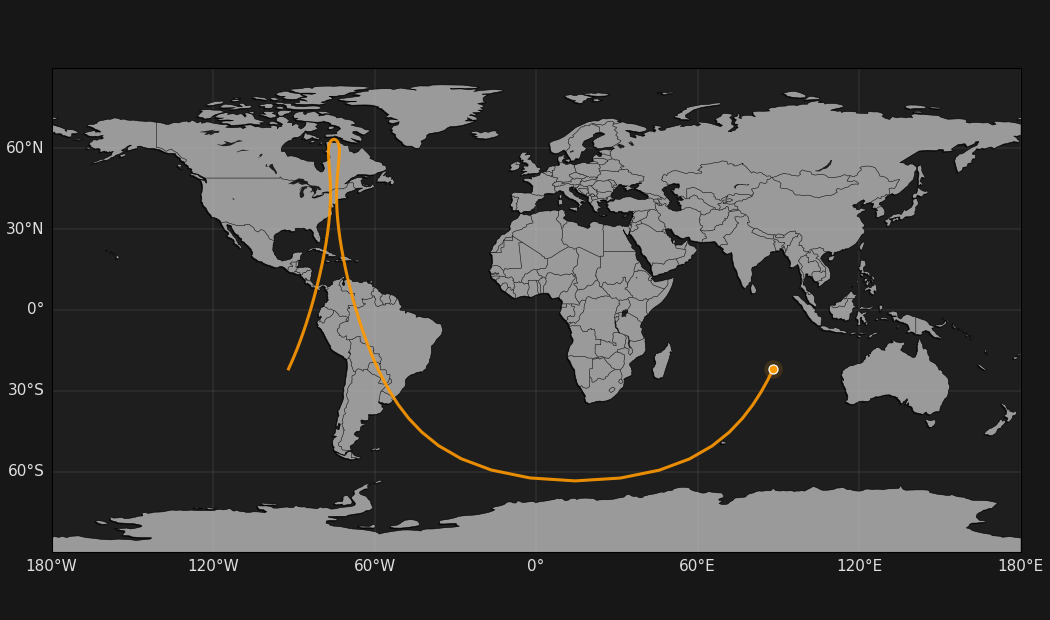

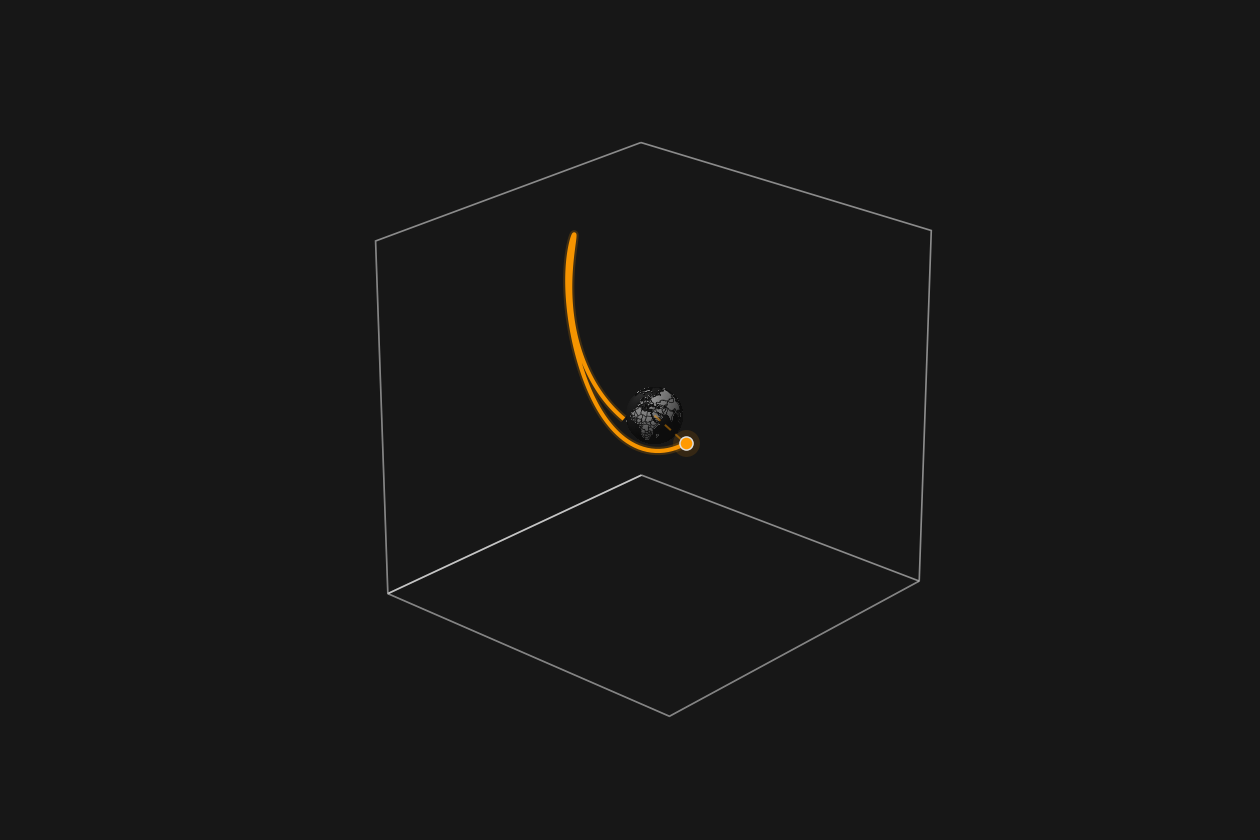

(<Figure size 1260x840 with 1 Axes>, <Axes3D: >)

In [4]:
# Quick look at the orbit geometry.
orbit.plot()
orbit.plot(view="3d")


## 2) Use one `sample(...)` call to get multiple vectorized outputs

The main `Orbit` method is `sample(...)`. Ask for the fields you want and it returns one structured `SampledStates` object containing NumPy arrays.


In [5]:
dt_s = np.linspace(0.0, 3.0 * 3600.0, 7, dtype=np.float64)

sampled = orbit.sample(
    dt_s,
    cartesian_frame="gcrf",
    position=True,
    velocity=True,
    attitude_reference_frame="gcrf",
    attitude_quat=True,
    attitude_spin=True,
)

print("available fields:", sampled.available_fields)
print("position shape:", sampled.position_m.shape)
print("velocity shape:", sampled.velocity_mps.shape)
print("quaternion shape:", sampled.attitude_quat_ref_to_body.shape)
print("spin shape:", sampled.attitude_spin_body_rad_s.shape)
print("first position sample [m]:", sampled.position_m[0])
print("first quaternion sample [q1, q2, q3, q4]:", sampled.attitude_quat_ref_to_body[0])
print("first body spin sample [rad/s]:", sampled.attitude_spin_body_rad_s[0])


available fields: ('position_m', 'velocity_mps', 'attitude_quat_ref_to_body', 'attitude_spin_body_rad_s')
position shape: (7, 3)
velocity shape: (7, 3)
quaternion shape: (7, 4)
spin shape: (7, 3)
first position sample [m]: [ 9618900.499621  1414849.586933 -3914696.561834]
first quaternion sample [q1, q2, q3, q4]: [-0.785354  0.099562  0.550758 -0.264523]
first body spin sample [rad/s]: [-0.       -0.000669 -0.      ]


## 3) Convenience getters stay simple

If you only need one thing, the explicit getters are often the shortest path. They all return floats / NumPy arrays with documented units.


In [6]:
position_itrf = orbit.get_position(dt_s, frame="itrf")
position_gcrf, velocity_gcrf = orbit.get_pv(dt_s, frame="gcrf")
kepler_deg = orbit.get_keplerian_classical(dt_s, frame="gcrf", degrees=True)
geodetic = orbit.get_geodetic(dt_s)

print("ITRF position shape:", position_itrf.shape)
print("GCRF PV shapes:", position_gcrf.shape, velocity_gcrf.shape)
print("Keplerian element shape:", kepler_deg.shape)
print("Geodetic shape:", geodetic.shape)
print("first geodetic sample [deg, deg, m]:", geodetic[0])


ITRF position shape: (7, 3)
GCRF PV shapes: (7, 3) (7, 3)
Keplerian element shape: (7, 6)
Geodetic shape: (7, 3)
first geodetic sample [deg, deg, m]: [    -21.868793     -91.968133 4105745.370044]


## 4) Time inputs are flexible

`Orbit` methods accept:
- seconds from epoch as floats / NumPy arrays
- `astropy.time.Time` scalars or vectors
- Orekit `AbsoluteDate` objects


In [7]:
t_seconds = np.array([0.0, 60.0, 120.0], dtype=np.float64)
t_astropy = Time(epoch.unix + t_seconds, format="unix", scale="utc")
t0 = astropy_time_to_orekit_date(epoch)
t_absolute = [t0.shiftedBy(float(dt)) for dt in t_seconds]

r_seconds = orbit.get_position(t_seconds, frame="gcrf")
r_astropy = orbit.get_position(t_astropy, frame="gcrf")
r_absolute = orbit.get_position(t_absolute, frame="gcrf")

print("allclose(seconds, astropy):", np.allclose(r_seconds, r_astropy))
print("allclose(seconds, AbsoluteDate):", np.allclose(r_seconds, r_absolute))


allclose(seconds, astropy): True
allclose(seconds, AbsoluteDate): True


## 5) Numerical propagators work the same way

Only the propagator builder changes. The `Orbit` interface stays the same.


In [8]:
propagator_num = build_numerical_propagator(
    epoch=epoch,
    a=7050e3,
    e=0.002,
    i=np.deg2rad(97.4),
    raan=np.deg2rad(5.0),
    argp=np.deg2rad(45.0),
    anomaly=np.deg2rad(0.0),
    anomaly_type="mean",
    inertial_frame="gcrf",
    gravity_degree=12,
    gravity_order=12,
    enable_third_body=True,
    third_bodies=("sun", "moon"),
    enable_srp=True,
    srp_area_m2=1.0,
    srp_cr=1.2,
    enable_drag=False,
)

orbit_num = Orbit(propagator_num, should_cache=True)
dense_dt = np.arange(0.0, 6.0 * 3600.0 + 60.0, 60.0, dtype=np.float64)

print("fresh numerical cache coverage:", orbit_num.coverage())
t0 = perf_counter()
_ = orbit_num.get_pv(dense_dt, frame="gcrf")
t1 = perf_counter()
print("after first dense query:", orbit_num.coverage())

orbit_num.clear_cache()
orbit_num.precompute(dense_dt[0], dense_dt[-1])
t2 = perf_counter()
_ = orbit_num.get_pv(dense_dt, frame="gcrf")
t3 = perf_counter()
print("after precompute:", orbit_num.coverage())
print(f"dense query without precompute: {t1 - t0:.3f} s")
print(f"precompute call: {t2 - t1:.3f} s")
print(f"dense query after precompute: {t3 - t2:.3f} s")


fresh numerical cache coverage: (0.0, 0.0)
after first dense query: (0.0, 21600.0)
after precompute: (0.0, 21600.0)
dense query without precompute: 0.117 s
precompute call: 0.112 s
dense query after precompute: 0.036 s


## 6) You can swap the attitude provider directly on `Orbit`

This keeps the wrapper easy to use for interactive work: build an orbit once, then replace the attitude law when you want a different attitude model.


In [9]:
t_att = np.array([0.0, 60.0, 120.0], dtype=np.float64)
q_default = orbit.get_attitude_quat(
    t_att,
    reference_frame="gcrf",
    quaternion_convention="scalar_last",
)

sun_constrained = build_ideal_nadir_sun_constrained_attitude_provider(
    inertial_frame="gcrf"
)
orbit.set_attitude_provider(sun_constrained)

q_sun = orbit.get_attitude_quat(
    t_att,
    reference_frame="gcrf",
    quaternion_convention="scalar_last",
)
w_sun = orbit.get_attitude_spin(t_att, reference_frame="gcrf")

print("attitude provider after update:", orbit.get_attitude_provider().getClass().getSimpleName())
print("default vs sun-constrained differs:", bool(not np.allclose(q_default, q_sun)))
print("first sun-constrained quaternion [q1, q2, q3, q4]:", q_sun[0])
print("first body spin sample [rad/s]:", w_sun[0])


attitude provider after update: AlignedAndConstrained
default vs sun-constrained differs: True
first sun-constrained quaternion [q1, q2, q3, q4]: [ 0.481782 -0.283689 -0.645617  0.520178]
first body spin sample [rad/s]: [ 0.000436  0.000509 -0.000083]


Next notebook: **02 - Transforms Usage**.
